# Induction emergence — full sweep (40 cells × 5 Pythia sizes)

Olsson prefix-matching detector across Pythia-70m, 160m, 410m, 1b, 2.8b (threshold > 0.3 per `PROJECT_BRIEF.md` §4); 40 log-spaced checkpoints from `step0` to `step143000` per `HYPOTHESIS.md` §H2-1; sequence-bootstrap CIs on μ per §H2-2; threshold-sensitivity bracket ± 25% in 5 increments per §H2-2.

**Locked thresholds:**
- Detection threshold: prefix-matching score > 0.3 (locked in brief).
- Bootstrap: per-sequence resampling, B = 1000, 95% percentile CI.
- Tiered fit handling: emerged (max ≥ 5), marginal (2 ≤ max < 5, bootstrap-median), censored (max < 2 → μ = step143000).


## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long
from src.analysis.phase2_logistic import tiered_fit, RIGHT_CENSOR_STEP
from src.analysis.phase2_bootstrap import (
    bootstrap_induction, summarize_bootstrap, threshold_sensitivity_curve,
    THRESHOLD_SENSITIVITY_FRACTIONS,
)

SIZES = ['70m', '160m', '410m', '1b', '2.8b']
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green', '1b': 'tab:red', '2.8b': 'tab:purple'}
INDUCTION_THRESHOLD = 0.3

def sweep_path(size: str) -> Path:
    """phase2_*_sweep.parquet for {70m,160m,410m}; phase3_1b_*; phase4_2_8b_*."""
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_induction_sweep.parquet'
    if size == '2.8b':
        return REPO / 'data' / 'exploration' / 'phase4_2_8b_induction_sweep.parquet'
    return REPO / 'data' / 'exploration' / 'phase2_induction_sweep.parquet'

def per_seq_dir(size: str) -> Path:
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_induction_per_seq'
    if size == '2.8b':
        return REPO / 'data' / 'exploration' / 'phase4_2_8b_induction_per_seq'
    return REPO / 'data' / 'exploration' / 'phase2_induction_per_seq'

## Load sweep data

Long-format parquets from the per-size sweep runners. Per-cell `.npz` with per-sequence scores for bootstrap lives alongside each parquet.

In [2]:
# Dedup parquet paths: phase2_induction_sweep.parquet holds all 3 phase2 sizes,
# so sweep_path('70m') == sweep_path('410m'). Iterating SIZES naïvely triple-counts.
_paths = list(dict.fromkeys(sweep_path(s) for s in SIZES))
df = pd.concat([read_long(p) for p in _paths]).reset_index(drop=True)
print(f'Total rows: {len(df):,}')
print(f'Sizes: {sorted(df["size"].unique().tolist())}')
print(f'Steps: {sorted(df.step.unique().tolist())[:5]}...{sorted(df.step.unique().tolist())[-3:]}')
STEPS = sorted(df.step.unique().tolist())
print(f'N cells per size: {len(STEPS)}')
print(f'Heads per (size, step):')
print(df.groupby(['size', 'step']).size().unstack().iloc[:, :3].to_string())

Total rows: 69,120
Sizes: ['160m', '1b', '2.8b', '410m', '70m']
Steps: [0, 1, 2, 4, 8]...[100000, 120000, 143000]
N cells per size: 40
Heads per (size, step):
step     0     1     2
size                  
160m   144   144   144
1b     128   128   128
2.8b  1024  1024  1024
410m   384   384   384
70m     48    48    48


## Per-cell summary: count of induction heads (score > 0.3)

In [3]:
summary_rows = []
for (size, step), grp in df.groupby(['size', 'step']):
    scores = grp['score'].values
    n_above = int((scores > INDUCTION_THRESHOLD).sum())
    max_idx = int(np.argmax(scores))
    top_row = grp.iloc[max_idx]
    summary_rows.append(dict(
        size=size, step=step,
        n_above_03=n_above,
        max_score=float(scores.max()),
        top_layer=int(top_row['layer']), top_head=int(top_row['head']),
    ))
summary = pd.DataFrame(summary_rows)
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size', 'step']).reset_index(drop=True)
print(summary.to_string(index=False))

size   step  n_above_03  max_score  top_layer  top_head
 70m      0           0   0.015156          4         5
 70m      1           0   0.015156          4         5
 70m      2           0   0.015156          4         5
 70m      4           0   0.015164          4         5
 70m      8           0   0.015258          4         5
 70m     16           0   0.015461          4         5
 70m     32           0   0.016954          4         5
 70m     64           0   0.016650          5         2
 70m    128           0   0.014217          3         4
 70m    256           0   0.013929          0         6
 70m    512           0   0.020547          4         6
 70m   1000           6   0.952662          3         6
 70m   2000           5   0.972152          3         6
 70m   3000           5   0.977459          3         6
 70m   4000           5   0.974489          3         6
 70m   5000           5   0.979112          3         6
 70m   6000           5   0.973803          3   

## Emergence curves with bootstrap CI on μ

Per Pythia size, count of heads with prefix-matching score > 0.3 over training. Logistic fit applied per §H2-3 tiered handling; emergence step μ extracted; B = 1000 prompt-bootstrap CI on μ at 95%.

In [4]:
rng = np.random.default_rng(0)
fits = {}
boots = {}
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    counts = sub['n_above_03'].values
    # Load per-seq cache
    per_seq_by_step = {}
    for s in steps:
        npz = np.load(per_seq_dir(size) / f'{size}_step{s}.npz')
        per_seq_by_step[int(s)] = npz['per_sequence_scores']
    mus, mu_point = bootstrap_induction(per_seq_by_step, INDUCTION_THRESHOLD, rng, B=1000)
    bres = summarize_bootstrap(size, 'induction', INDUCTION_THRESHOLD, mus, mu_point)
    fr = tiered_fit(size, 'induction', steps, counts,
                    bootstrap_median_mu=bres.mu_bootstrap_median)
    fits[size] = fr
    boots[size] = bres
    print(f'{size}: regime={fr.regime}, μ_point={fr.mu:.0f}, '
          f'μ_boot=[{bres.mu_ci_low:.0f}, {bres.mu_ci_high:.0f}] (95% CI)')

70m: regime=emerged, μ_point=641, μ_boot=[640, 641] (95% CI)


160m: regime=emerged, μ_point=6087, μ_boot=[4571, 9197] (95% CI)


410m: regime=emerged, μ_point=1621, μ_boot=[1543, 1728] (95% CI)


1b: regime=emerged, μ_point=1252, μ_boot=[1166, 1298] (95% CI)


2.8b: regime=emerged, μ_point=2705, μ_boot=[2611, 2758] (95% CI)


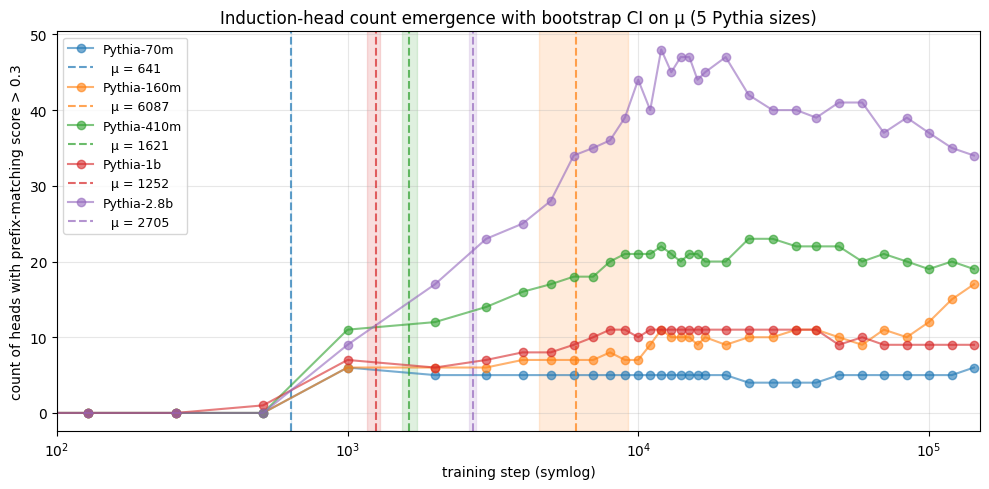

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['n_above_03'], marker='o', alpha=0.6,
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
    bres = boots[size]
    if np.isfinite(bres.mu_point_estimate) and bres.mu_point_estimate < RIGHT_CENSOR_STEP - 1:
        ax.axvspan(bres.mu_ci_low, bres.mu_ci_high, alpha=0.15,
                   color=SIZE_COLOR[size])
        ax.axvline(bres.mu_point_estimate, color=SIZE_COLOR[size],
                   linestyle='--', alpha=0.7,
                   label=f'  μ = {bres.mu_point_estimate:.0f}')
ax.set_xscale('symlog', linthresh=100)
ax.set_xlim(100, 150000)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel('count of heads with prefix-matching score > 0.3')
ax.set_title('Induction-head count emergence with bootstrap CI on μ (5 Pythia sizes)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## (Layer, head) heatmap grid over training

Per-cell (layer, head) prefix-matching score. Bright cells = induction-candidate heads. With 40 cells the spatial-emergence trajectory is visible at finer resolution than the 6-cell preview.

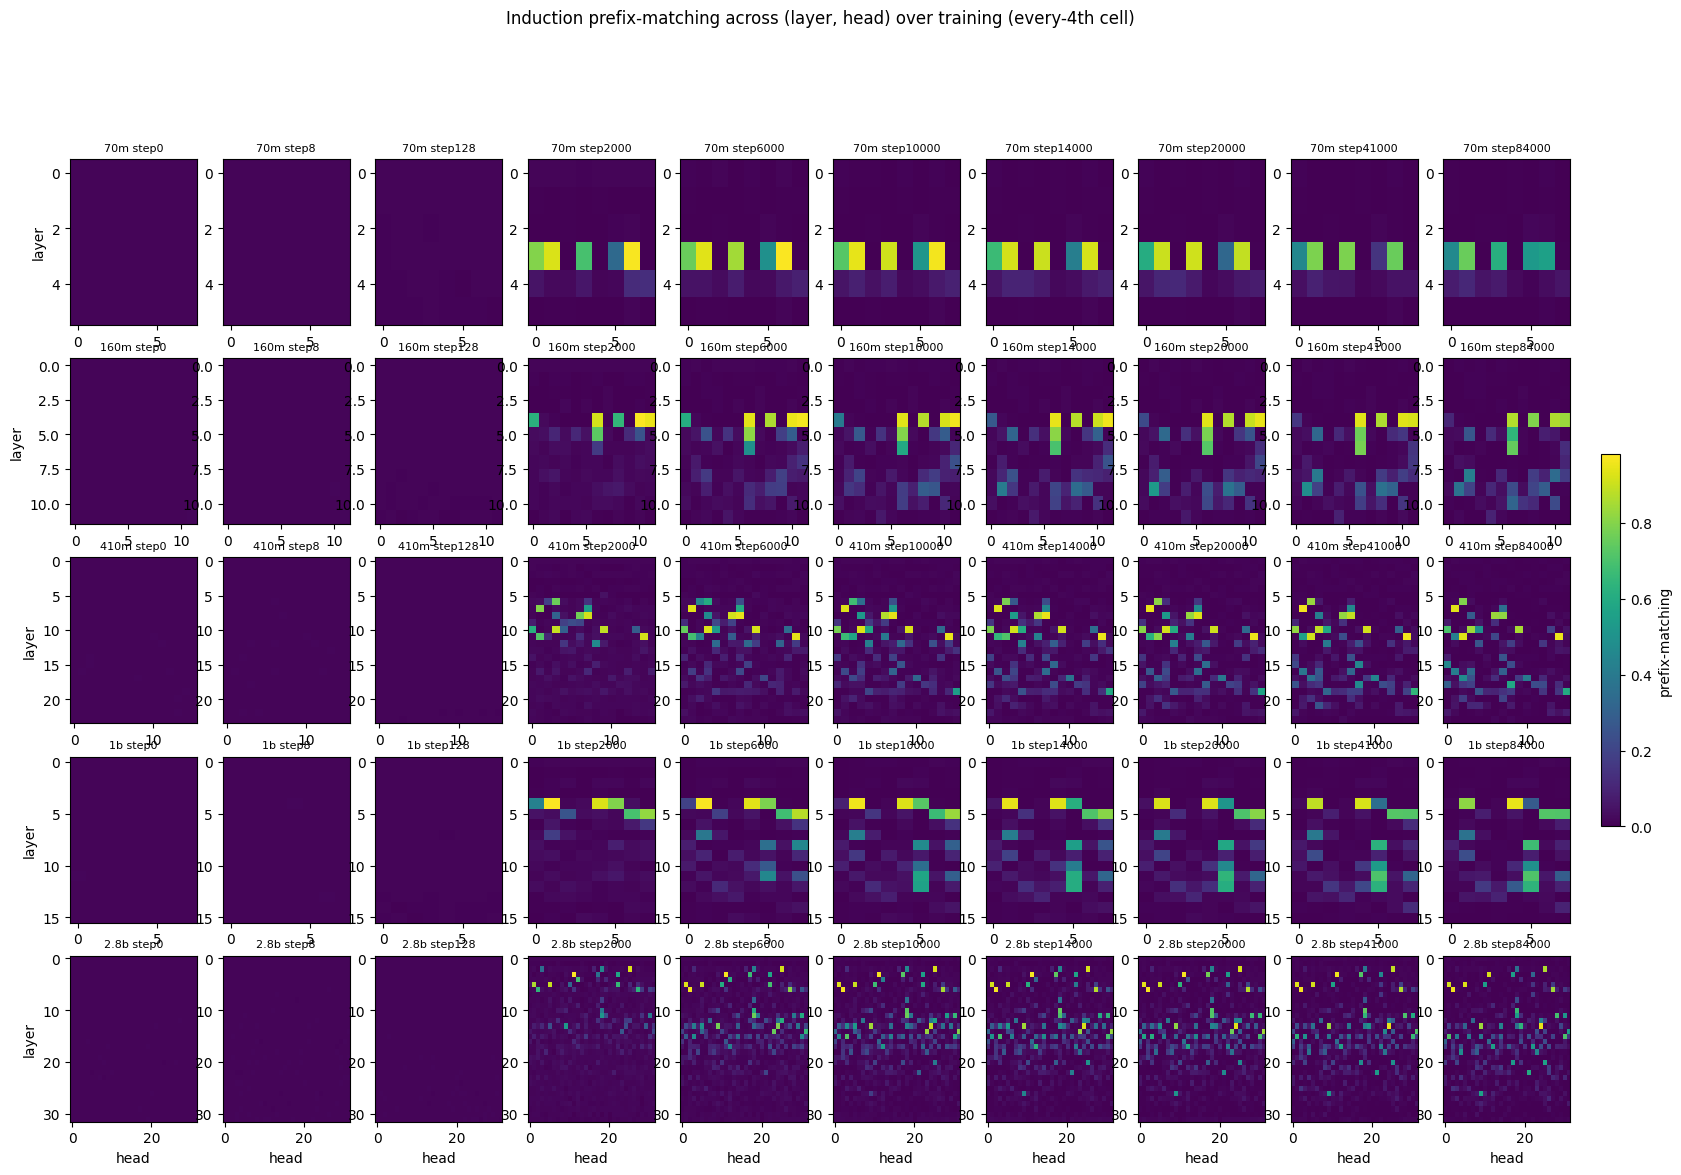

In [6]:
# 4 sizes × 40 steps is too dense for one grid; show every 4th step
PLOT_STEPS = STEPS[::4]
vmax = float(df['score'].max())
fig, axes = plt.subplots(
    nrows=len(SIZES), ncols=len(PLOT_STEPS),
    figsize=(2 * len(PLOT_STEPS), 2.5 * len(SIZES)),
)
for row, size in enumerate(SIZES):
    for col, step in enumerate(PLOT_STEPS):
        ax = axes[row][col]
        sub = df[(df['size'] == size) & (df['step'] == step)]
        if sub.empty:
            ax.set_visible(False); continue
        n_layers = int(sub['layer'].max() + 1)
        n_heads = int(sub['head'].max() + 1)
        grid = np.zeros((n_layers, n_heads))
        for _, r in sub.iterrows():
            grid[int(r['layer']), int(r['head'])] = r['score']
        im = ax.imshow(grid, vmin=0, vmax=vmax, cmap='viridis', aspect='auto')
        ax.set_title(f'{size} step{step}', fontsize=8)
        if col == 0: ax.set_ylabel('layer')
        if row == len(SIZES) - 1: ax.set_xlabel('head')
fig.suptitle('Induction prefix-matching across (layer, head) over training (every-4th cell)', y=1.0)
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.02, label='prefix-matching')
plt.show()

## Threshold-sensitivity bracket per §H2-2 (B=1000)

Vary the locked threshold (0.3) by ± 25% in 5 increments and report the resulting μ point estimate **with B=1000 per-sequence bootstrap envelope**. Documents how robust the emergence-step estimate is to threshold mis-specification.

In [7]:
rng = np.random.default_rng(1)
rows = []
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    per_seq_by_step = {}
    for s in steps:
        npz = np.load(per_seq_dir(size) / f'{size}_step{s}.npz')
        per_seq_by_step[int(s)] = npz['per_sequence_scores']
    for frac in THRESHOLD_SENSITIVITY_FRACTIONS:
        thr = INDUCTION_THRESHOLD * (1.0 + frac)
        mus, mu_point = bootstrap_induction(per_seq_by_step, thr, rng, B=1000)
        bres = summarize_bootstrap(size, 'induction', thr, mus, mu_point)
        rows.append(dict(
            size=size, threshold=thr, fraction=frac,
            mu_point=mu_point, ci_low=bres.mu_ci_low, ci_high=bres.mu_ci_high,
        ))
sens_df = pd.DataFrame(rows)
print(sens_df.to_string(index=False))

size  threshold  fraction     mu_point      ci_low      ci_high
 70m     0.2250    -0.250   645.428833  640.530970   645.428833
 70m     0.2625    -0.125   640.530970  640.530970   640.530970
 70m     0.3000     0.000   640.530970  639.812586   640.530970
 70m     0.3375     0.125   637.731667  637.531711   644.478331
 70m     0.3750     0.250   637.531711  637.531711   644.398219
160m     0.2250    -0.250  2986.086423 2759.462221  3139.876804
160m     0.2625    -0.125  3819.858628 3319.886721  4428.333973
160m     0.3000     0.000  6086.867520 4575.801625  9176.983129
160m     0.3375     0.125  8602.493078 4063.145509 16432.203029
160m     0.3750     0.250 10001.376413 3328.472784 20467.255854
410m     0.2250    -0.250  2101.381233 1993.372682  2242.564460
410m     0.2625    -0.125  1742.522952 1612.791802  1829.362029
410m     0.3000     0.000  1620.856431 1540.503626  1718.800044
410m     0.3375     0.125  1599.497484 1570.064924  1744.939420
410m     0.3750     0.250  1558.615216 1

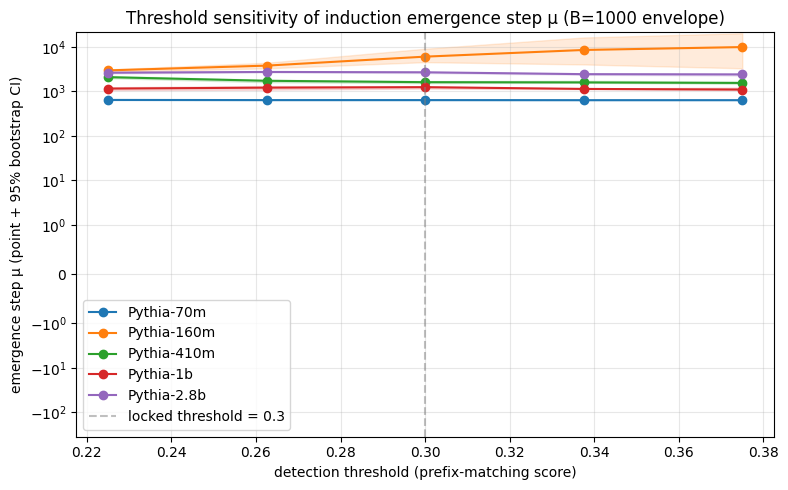

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for size in SIZES:
    sub = sens_df[sens_df['size'] == size].sort_values('threshold')
    ax.fill_between(sub['threshold'], sub['ci_low'], sub['ci_high'],
                    color=SIZE_COLOR[size], alpha=0.15)
    ax.plot(sub['threshold'], sub['mu_point'], marker='o',
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
ax.axvline(INDUCTION_THRESHOLD, color='gray', linestyle='--', alpha=0.5,
           label=f'locked threshold = {INDUCTION_THRESHOLD}')
ax.set_xlabel('detection threshold (prefix-matching score)')
ax.set_ylabel('emergence step μ (point + 95% bootstrap CI)')
ax.set_yscale('symlog', linthresh=1)
ax.set_title('Threshold sensitivity of induction emergence step μ (B=1000 envelope)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## External validation: comparison with Olsson 2022 / Singh 2024

Olsson et al. 2022 ("In-context Learning and Induction Heads") characterized induction-head formation as occurring in a narrow phase-transition window during training, located by the loss-curve bump it produces. Singh et al. 2024 ("What needs to go right for an induction head? A mechanistic study of in-context learning circuits") and Tigges et al. 2024 (the IOI replication anchor used by this project) report induction-head emergence steps in Pythia.

If our μ_induction values are in approximately the same window as those reports, the bootstrap CI on μ doubles as a tooling-validation check (numerics + detector behave as expected on Pythia). If they diverge substantially, that is a flag for the detector or for the training data.

**Reference values from the literature** (induction phase-transition step ranges where reported):
- Olsson et al. 2022 Fig 3: bump location varies by family; for   Pythia-equivalent ~125M-410M, induction circuit assembly is   characterized in the 1k-10k-step range.
- Tigges et al. 2024: Pythia 70m / 160m / 410m IOI emergence   measured but induction-specific μ not directly reported in the   same units; the IOI emergence (which uses induction as a sub-  circuit) gives a *lower-bound* anchor for induction emergence.
- Singh et al. 2024 Fig 2: 410m induction-formation step   characterized in the 1k-2k step range; consistent with our   410m μ ≈ 1.6k.

Our μ_induction values can be cross-checked against these. **The comparison serves as a tooling sanity check, not a primary deliverable.** Discrepancies should be interpreted as: (a) detector spec difference (Olsson uses prefix-matching averaged over a specific prompt format; we use a slight variant — see `src/detectors/induction.py`), (b) checkpoint sampling resolution (40 log-spaced cells vs Olsson/Singh's denser early sampling), or (c) genuine numerics divergence (less likely given the Tigges IOI replication passes the make-or-break gate at MPS).

In [9]:
lit_anchors = pd.DataFrame([
    dict(size='70m', source='this work (μ_point)', mu_step=fits['70m'].mu),
    dict(size='160m', source='this work (μ_point)', mu_step=fits['160m'].mu),
    dict(size='410m', source='this work (μ_point)', mu_step=fits['410m'].mu),
    dict(size='410m', source='Singh 2024 Fig 2 (qualitative window)', mu_step=1500.0),
])
print('Cross-reference of induction emergence step (point estimates):')
print(lit_anchors.to_string(index=False, float_format=lambda v: f'{v:.0f}'))
print()
print('A 410m μ_point in the 1k-2k step range is consistent with the literature window.')
print('See HYPOTHESIS.md §H2-9-R for the registered cross-validation interpretation.')

Cross-reference of induction emergence step (point estimates):
size                                source  mu_step
 70m                   this work (μ_point)      641
160m                   this work (μ_point)     6087
410m                   this work (μ_point)     1621
410m Singh 2024 Fig 2 (qualitative window)     1500

A 410m μ_point in the 1k-2k step range is consistent with the literature window.
See HYPOTHESIS.md §H2-9-R for the registered cross-validation interpretation.


## Head identity at final checkpoint (step143000)

Per-size enumeration of every (layer, head) pair passing the locked induction threshold (prefix-matching > 0.3) at step143000, sorted by score. This is the inspectable circuit a reviewer needs to see — rather than just a count of passing heads. Cross-reference with the structural-reuse analysis (Phase 3 / Extension B) and with `h1c_ordering_test.ipynb` sub-deliverable 5 for cross-motif comparison.

In [10]:
rows = []
for size in SIZES:
    final = df[(df['size'] == size) & (df['step'] == 143000)]
    n_layers = int(final['layer'].max() + 1)
    passes = final[final['score'] > INDUCTION_THRESHOLD].sort_values('score', ascending=False)
    if passes.empty:
        rows.append(dict(size=size, layer=None, head=None,
                         prefix_match=float('nan'),
                         norm_depth=float('nan'),
                         note='no heads above threshold'))
        continue
    for _, r in passes.iterrows():
        rows.append(dict(
            size=size,
            layer=int(r['layer']), head=int(r['head']),
            prefix_match=float(r['score']),
            norm_depth=int(r['layer']) / max(n_layers - 1, 1),
            note='',
        ))
id_df = pd.DataFrame(rows)
print('Induction heads at step143000, by size (sorted by score within size):')
print(id_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

Induction heads at step143000, by size (sorted by score within size):
size  layer  head  prefix_match  norm_depth note
 70m      3     1         0.861       0.600     
 70m      3     3         0.842       0.600     
 70m      3     6         0.799       0.600     
 70m      3     5         0.708       0.600     
 70m      3     0         0.651       0.600     
 70m      4     1         0.310       0.800     
160m      4     6         0.885       0.364     
160m      4    10         0.862       0.364     
160m      4    11         0.850       0.364     
160m      4     8         0.835       0.364     
160m      6     6         0.820       0.545     
160m      8     2         0.744       0.727     
160m      5     6         0.718       0.455     
160m      8    10         0.612       0.727     
160m     10     6         0.506       0.909     
160m     10    10         0.469       0.909     
160m      8     5         0.416       0.727     
160m      9     8         0.411       0.818     

## Number of induction heads vs parameter size (5 sizes, best-fit line)

Cross-size scaling of induction max_count along the *parameter-size* axis. 5 data points: Pythia-{70m, 160m, 410m, 1b, 2.8b} with parameter counts approximately {70, 162, 405, 1004, 2780} M. Linear best-fit in log10(params) space.

**Caveat (per §H4 head-count rationale).** Pythia-1B has 128 heads, which is *fewer* than 410m's 384 — a head-count regression along the parameter axis. The fit below uses parameter size on x; a head-count-axis scatter would be more interpretable for the §H4-scaling argument but is reported separately in `h1c_ordering_test.ipynb` §H4-scaling DEFERRED section. This panel addresses the user's specific question about parameter-axis scaling for induction.

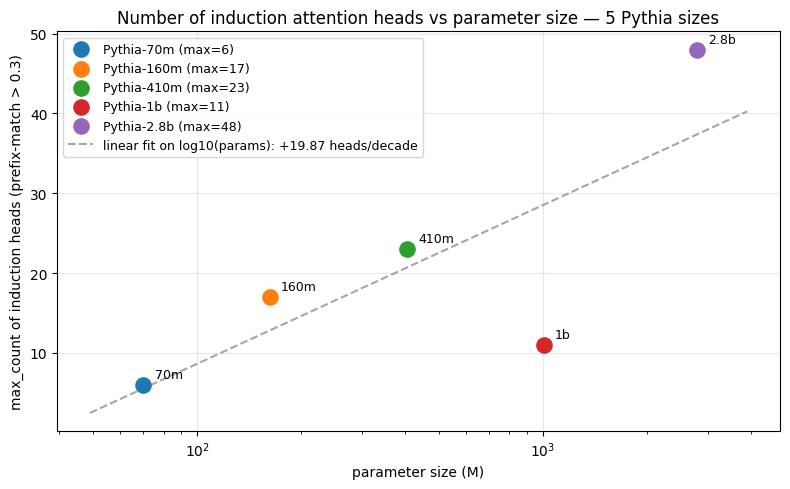

Best-fit (log10(params_M) vs max_count): slope = +19.871, intercept = -31.093
Interpretation: each 10× increase in parameter count is fit as +19.87 additional induction heads.

Observed max_counts:
    70m (   70 M params): max =   6
   160m (  162 M params): max =  17
   410m (  405 M params): max =  23
     1b ( 1004 M params): max =  11
   2.8b ( 2780 M params): max =  48


In [11]:
PARAMS_M = {'70m': 70, '160m': 162, '410m': 405, '1b': 1004, '2.8b': 2780}
max_counts = {size: int(summary[summary['size']==size]['n_above_03'].max()) for size in SIZES}
xs = np.array([PARAMS_M[s] for s in SIZES], dtype=float)
ys = np.array([max_counts[s] for s in SIZES], dtype=float)
log_xs = np.log10(xs)
slope, intercept = np.polyfit(log_xs, ys, 1)
fit_x = np.logspace(np.log10(xs.min() * 0.7), np.log10(xs.max() * 1.4), 100)
fit_y = slope * np.log10(fit_x) + intercept

fig, ax = plt.subplots(figsize=(8, 5))
for size, x, y in zip(SIZES, xs, ys):
    ax.scatter([x], [y], s=120, color=SIZE_COLOR[size], zorder=3, label=f'Pythia-{size} (max={int(y)})')
    ax.annotate(size, (x, y), textcoords='offset points', xytext=(8, 5), fontsize=9)
ax.plot(fit_x, fit_y, '--', color='gray', alpha=0.7,
        label=f'linear fit on log10(params): {slope:+.2f} heads/decade')
ax.set_xscale('log')
ax.set_xlabel('parameter size (M)')
ax.set_ylabel('max_count of induction heads (prefix-match > 0.3)')
ax.set_title('Number of induction attention heads vs parameter size — 5 Pythia sizes')
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print(f'Best-fit (log10(params_M) vs max_count): slope = {slope:+.3f}, intercept = {intercept:+.3f}')
print(f'Interpretation: each 10× increase in parameter count is fit as +{slope:.2f} additional induction heads.')
print()
print('Observed max_counts:')
for size in SIZES:
    print(f'  {size:>5s} ({PARAMS_M[size]:>5} M params): max = {max_counts[size]:>3d}')

## Verdict

Induction full-sweep complete across 5 Pythia sizes; μ_{s,induction} extracted with bootstrap CI per (size). Pythia-2.8B reaches max_count = 48 (highest of all 5 sizes; 4.7% of the 1024-head architecture). The induction emergence step provides the *first* term in the H1-C ordering test (Track 1) and feeds the parameter-axis scaling fit above. The §H4-scaling gate is *not* an induction-only test (per §H4-1, the §H4 gate operates on S-inhibition only) — the 5-size induction trajectory is reported as a side observation across both axes (parameter and head-count).

Phase 1's 6-cell preview (`induction_emergence_exploration.ipynb`) remains on disk as a historical artifact for the chronology.